In [ ]:
#importing the dependacies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
import json
import pandas as pd

def load_and_combine_datasets(legit_path, phishing_path):
    # Load legitimate URLs
    with open(legit_path, 'r') as f:
        legitimate_urls = json.load(f)

    # Load phishing URLs
    with open(phishing_path, 'r') as f:
        phishing_urls = json.load(f)

    # Create DataFrames with labels
    df_legit = pd.DataFrame({'url': legitimate_urls, 'label': 'legitimate'})
    df_phish = pd.DataFrame({'url': phishing_urls, 'label': 'phishing'})

    # Combine the datasets
    df_combined = pd.concat([df_legit, df_phish], ignore_index=True)

    # Shuffle the combined dataset
    df_combined = df_combined.sample(frac=1).reset_index(drop=True)

    return df_combined

# Set file paths
legit_path = '/content/data_legitimate_36400.json'
phishing_path = '/content/data_phishing_37175.json'

# Get combined dataset
df = load_and_combine_datasets(legit_path, phishing_path)

# Print some rows to check
print("df (first 10 rows):")
print(df.head(10))  # change the number as needed

# Optional: save to CSV
df.to_csv('phising_url_dataset.csv', index=False)


df (first 10 rows):
                                                 url       label
0  http://docs.trendmicro.com/all/ent/officescan/...  legitimate
1  http://noticias-casera.net/noticias-casera/app...    phishing
2  http://livrariaeducacao.net.br/wp-admin/projec...    phishing
3  http://www.mindmatterstexas.com/adim/www.ourti...    phishing
4  http://www.nnordson.com/%7b%7d/781687308acaa5e...    phishing
5  http://www.wire2wire.org/Can_sniffer/Can_sniff...  legitimate
6        https://www.youtube.com/watch?v=R__XFpVNZvQ  legitimate
7            http://www.plentyfishof.com/delete-pof/  legitimate
8       http://mzansinet.co.za/log/all/d/DHL%20AUTO/    phishing
9    http://reforma.com.tr/img/retina/shop/sync/sync    phishing


In [ ]:
#printing the datset
print(df)

                                                     url       label
0      http://docs.trendmicro.com/all/ent/officescan/...  legitimate
1      http://noticias-casera.net/noticias-casera/app...    phishing
2      http://livrariaeducacao.net.br/wp-admin/projec...    phishing
3      http://www.mindmatterstexas.com/adim/www.ourti...    phishing
4      http://www.nnordson.com/%7b%7d/781687308acaa5e...    phishing
...                                                  ...         ...
73570  http://thrive-therapy.org/update/4094720bb4a55...    phishing
73571  http://tvapppay.com/abolo2/aloma/915f4443b5c7e...    phishing
73572  http://www.yourdictionary.com/digital-camera-f...  legitimate
73573  http://gameaccessibilityguidelines.com/does-ge...  legitimate
73574                  https://ru.wikipedia.org/wiki/CNN  legitimate

[73575 rows x 2 columns]


In [ ]:
#printing first 5 rows of dataset
df.head()

,url,label
0,http://docs.trendmicro.com/all/ent/officescan/...,legitimate
1,http://noticias-casera.net/noticias-casera/app...,phishing
2,http://livrariaeducacao.net.br/wp-admin/projec...,phishing
3,http://www.mindmatterstexas.com/adim/www.ourti...,phishing
4,http://www.nnordson.com/%7b%7d/781687308acaa5e...,phishing


In [ ]:
df.tail()

,url,label
73570,http://thrive-therapy.org/update/4094720bb4a55...,phishing
73571,http://tvapppay.com/abolo2/aloma/915f4443b5c7e...,phishing
73572,http://www.yourdictionary.com/digital-camera-f...,legitimate
73573,http://gameaccessibilityguidelines.com/does-ge...,legitimate
73574,https://ru.wikipedia.org/wiki/CNN,legitimate


In [ ]:
#data analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73575 entries, 0 to 73574
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     73575 non-null  object
 1   label   73575 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [ ]:
df.shape

(73575, 2)

In [ ]:
df.isnull().sum()

,0
url,0
label,0


In [ ]:
#finding count of different type
df['label'].value_counts()

,count
label,
phishing,37175
legitimate,36400


<Axes: xlabel='label'>

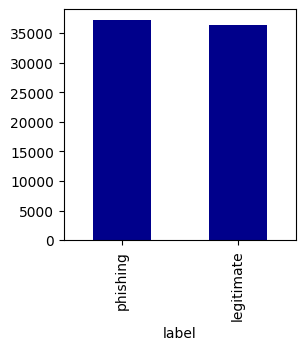

In [ ]:
#bar plot for different types of url
df['label'].value_counts().plot(kind='bar',color='darkblue',figsize=(3,3))


In [ ]:
#text preprocessing
#using wordcloud of nlp to find the distribution in above two cases to gt most of the tokens distribution in different types of url
from wordcloud import WordCloud

In [ ]:
#divivding the dataset into two different classes to draw there wordcloud individually
phising=df[df.label=='phishing']
legitimate=df[df.label=='legitimate']

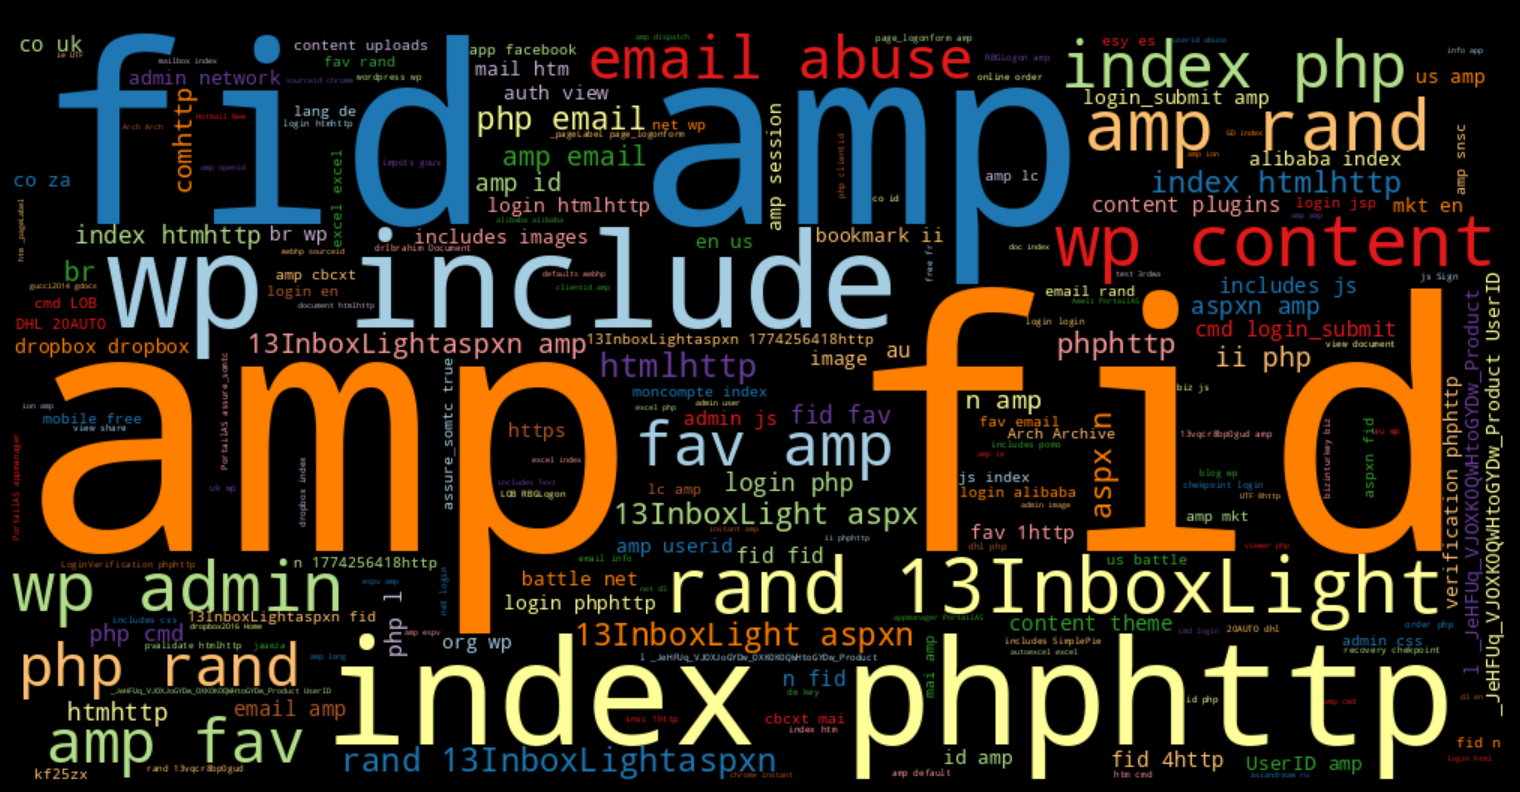

In [ ]:
#wordcloud for phising url
phising_url=''.join(list(phising.url.values))
wordcloud=WordCloud(width=1000,height=500,colormap='Paired').generate(phising_url)
plt.figure(figsize=(15,15),facecolor='k')
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Phishing URL')
plt.tight_layout(pad=0)
plt.savefig("phishing wordcloud.pdf")
plt.show()

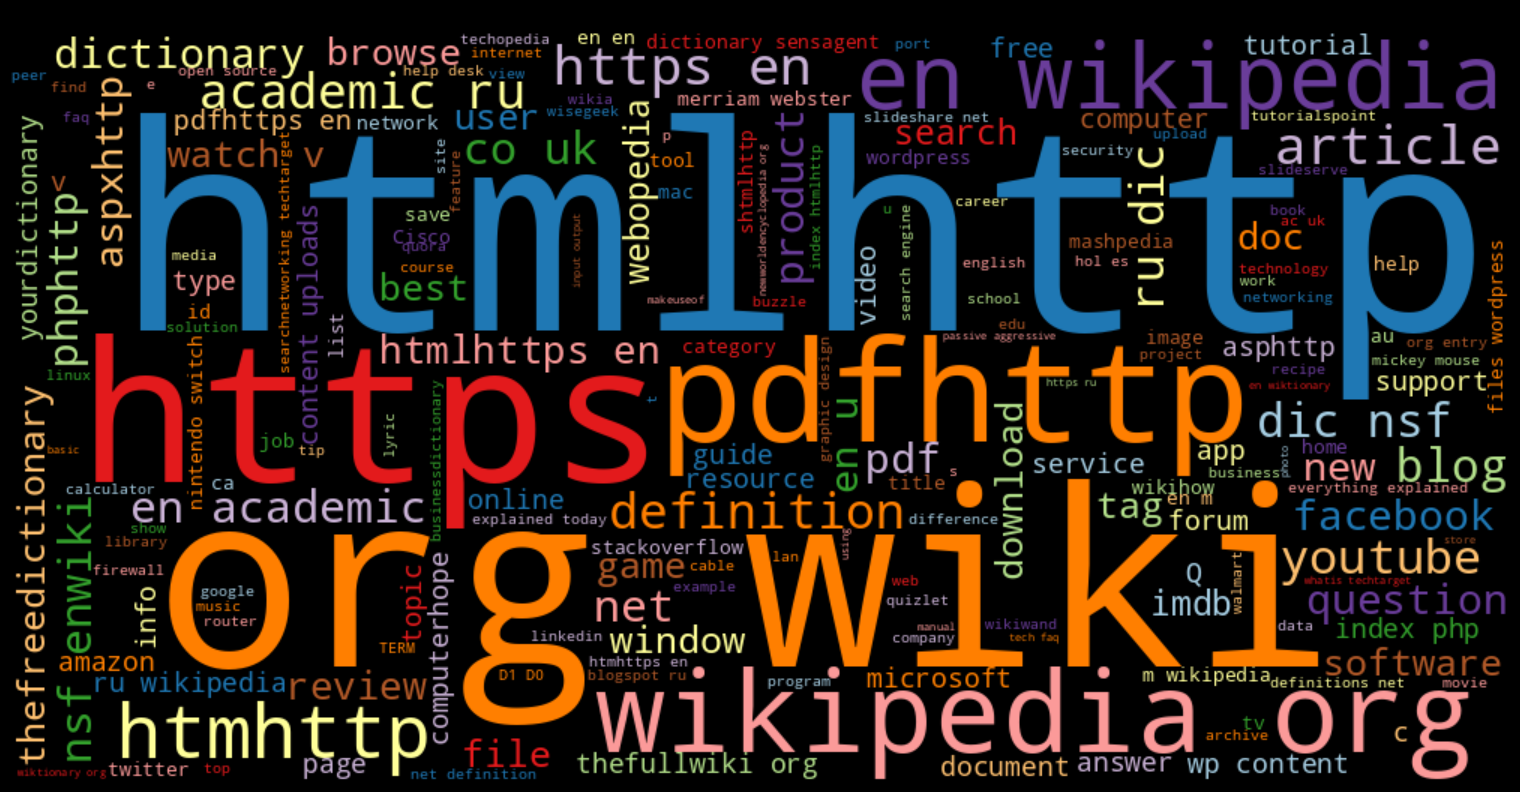

In [ ]:
#wordcloud for legitimate
benign_url=''.join(list(legitimate.url.values))
wordcloud=WordCloud(width=1000,height=500,colormap='Paired').generate(benign_url)
plt.figure(figsize=(15,15),facecolor='k')
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('legitimate URL')
plt.tight_layout(pad=0)
plt.savefig("legitimate wordcloud.pdf")
plt.show()

In [ ]:
##since ml model understands only numerical data we will try to extract important features from urlss to determine whether they are safe or not


In [ ]:
!pip install tldextract
# Required libraries
import pandas as pd
import numpy as np
import re
import string
import tldextract # This line will now work
from urllib.parse import urlparse
from difflib import SequenceMatcher

# Optional: Install missing packages
# !pip install tldextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 3.8 MB/s eta 0:00:00


In [ ]:
# Sample brand names and keywords — expand this list as needed
brand_names = ["paypal", "apple", "google", "amazon", "facebook", "netflix", "microsoft", "linkedin"]
keywords = ["login", "secure", "account", "update", "verify", "signin", "password", "support"]
target_brand_names = ["paypal", "apple"]  # Adjust based on your use case
target_keywords = ["login", "verify", "account"]

# Sample English words for random word check
# For full version, use a proper dictionary like `nltk.corpus.words.words()`
english_words = set(["computer", "pencil", "notebook", "table", "login", "user", "admin", "secure"])


In [ ]:
def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def is_random(word):
    return (
        len(word) >= 6
        and word.isalnum()
        and word.lower() not in english_words
        and not any(b in word.lower() for b in brand_names)
        and not any(k in word.lower() for k in keywords)
    )

def extract_url_features(url):
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain
    subdomain = ext.subdomain
    path = parsed.path
    tld = ext.suffix

    # Split into words using special characters
    raw_words = re.split(r'[\/:\.?&=_\-@]', url)
    raw_words = [w for w in raw_words if w]

    # Word lengths
    word_lengths = [len(w) for w in raw_words]
    avg_word_len = np.mean(word_lengths) if word_lengths else 0
    longest_word_len = max(word_lengths) if word_lengths else 0
    shortest_word_len = min(word_lengths) if word_lengths else 0
    std_word_len = np.std(word_lengths) if word_lengths else 0

    # WDM module (adjacent words and decomposition) — simplified
    adjacent_words = [w for w in raw_words if len(w) > 12]
    separated_words = sum(len(re.findall(r'[a-zA-Z]{4,}', w)) for w in adjacent_words)


    # Character counts
    digit_count = sum(c.isdigit() for c in url)
    special_chars = "-./@?&=_"
    special_char_count = sum(url.count(c) for c in special_chars)


def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def is_random(word):
    return (
        len(word) >= 6
        and word.isalnum()
        and word.lower() not in english_words
        and not any(b in word.lower() for b in brand_names)
        and not any(k in word.lower() for k in keywords)
    )

def extract_url_features(url):
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain
    subdomain = ext.subdomain
    path = parsed.path
    tld = ext.suffix

    # Split into words using special characters
    raw_words = re.split(r'[\/:\.?&=_\-@]', url)
    raw_words = [w for w in raw_words if w]

    # Word lengths
    word_lengths = [len(w) for w in raw_words]
    avg_word_len = np.mean(word_lengths) if word_lengths else 0
    longest_word_len = max(word_lengths) if word_lengths else 0
    shortest_word_len = min(word_lengths) if word_lengths else 0
    std_word_len = np.std(word_lengths) if word_lengths else 0

    # WDM module (adjacent words and decomposition) — simplified
    adjacent_words = [w for w in raw_words if len(w) > 12]
    separated_words = sum(len(re.findall(r'[a-zA-Z]{4,}', w)) for w in adjacent_words)


    # Character counts
    digit_count = sum(c.isdigit() for c in url)
    special_chars = "-./@?&=_"
    special_char_count = sum(url.count(c) for c in special_chars)

    return {
        "url": url,
        "raw_word_count": len(raw_words),
        "brand_in_domain":1 if any(b in domain.lower() for b in brand_names) else 0,
        "brand_in_path":1 if any(b in path.lower() for b in brand_names) else 0,
        "avg_word_len": avg_word_len,
        "longest_word_len": longest_word_len,
        "shortest_word_len": shortest_word_len,
        "std_word_len": std_word_len,
        "adjacent_word_count": len(adjacent_words),
        "avg_adjacent_word_len": np.mean([len(w) for w in adjacent_words]) if adjacent_words else 0,
        "separated_word_count": separated_words,
        "keyword_count": sum(url.lower().count(k) for k in keywords),
        "brand_name_count": sum(url.lower().count(b) for b in brand_names),
        "similar_keyword_count": sum(similar(w.lower(), k) > 0.8 for w in raw_words for k in keywords),
        "similar_brand_name_count": sum(similar(w.lower(), b) > 0.8 for w in raw_words for b in brand_names),
        "random_word_count": sum(1 for w in raw_words if is_random(w)),
        "target_brand_name_count": sum(url.lower().count(b) for b in target_brand_names),
        "target_keyword_count": sum(url.lower().count(k) for k in target_keywords),
        "other_english_words_count": sum(1 for w in raw_words if w.lower() in english_words and w.lower() not in brand_names + keywords),
        "digit_count": digit_count,
        "subdomain_count": subdomain.count('.') + 1 if subdomain else 0,
        "random_domain": is_random(domain),
        "domain_length": len(domain),
        "subdomain_length": len(subdomain),
        "path_length": len(path),
        "known_tld":1 if tld in ["com", "org", "net", "de", "edu", "gov"] else 0,
        "has_www": 1 if  'www' in subdomain else 0,
        "has_com":1  if'com' in domain else 0,

        "uses_punycode":1 if 'xn--' in domain else 0,

        "special_char_count": special_char_count,
        "consecutive_char_repeat": bool(re.search(r'(.)\1{2,}', url)),
        "alexa_top": 0,  # Placeholder, needs external list/API
        "alexa_rank": -1,  # Placeholder
        "total_url_length": len(url),
        "path_has_keywords": int(any(k in path.lower() for k in keywords)),
        "domain_has_hyphen": 1 if '-' in domain else 0,
        "starts_with_http": 1 if  url.startswith("http") else 0,

        "contains_ip_address": 1 if  bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', url)) else 0,
        "contains_port_number":1 if ':' in parsed.netloc and parsed.netloc.split(':')[-1].isdigit() else 0,
        "query_length": len(parsed.query),
        "fragment_length": len(parsed.fragment),
    }


In [ ]:
# Apply the feature extraction function to each URL
features = df['url'].apply(extract_url_features)

# Convert list of dicts to DataFrame
df_features = pd.DataFrame(features.tolist())

# Optional: merge back with original labels
df_final = pd.concat([df.label,df_features], axis=1)
#save df_final to a dataframe
df_final.to_csv('df_final.csv', index=False)

# Preview
df_final.head(5)


,label,url,raw_word_count,brand_in_domain,brand_in_path,avg_word_len,longest_word_len,shortest_word_len,std_word_len,adjacent_word_count,...,alexa_top,alexa_rank,total_url_length,path_has_keywords,domain_has_hyphen,starts_with_http,contains_ip_address,contains_port_number,query_length,fragment_length
0,phishing,http://tinggiba.co.id/owo/kungt/GD/,7,0,0,3.714286,8,2,2.050386,0,...,0,-1,35,0,0,1,0,0,0,0
1,phishing,http://talyavylyt.com/wp-includes/js/login.jsp...,9,0,0,4.444444,10,2,2.629369,0,...,0,-1,50,1,0,1,0,0,0,0
2,phishing,http://ambrosecourt.com/Our/Ourtime/ourtime.html,7,0,0,5.714286,12,3,3.010187,0,...,0,-1,48,0,0,1,0,0,0,0
3,legitimate,https://speed-new.com/muppets-inside-full-pc-game,9,0,0,4.333333,7,2,1.490712,0,...,0,-1,49,0,1,1,0,0,0,0
4,legitimate,http://www.tridimake.com/2012/10/the-software-...,12,0,0,4.166667,9,2,2.074983,0,...,0,-1,63,0,0,1,0,0,0,0


In [ ]:
#converting text  to vectors
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [ ]:
# Assuming df_final has: 'url', numerical_features, and 'is_phishing'
urls = df_final['url']  # Text column to vectorize
numerical_features = df_final.drop(columns=['url', 'label'])  # Handcrafted features
y = df_final['label']  # Target labels

In [ ]:
#  Label Encode y
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
# Extract 1701 word-based features from URLs
vectorizer = CountVectorizer(
    max_features=1700,
    ngram_range=(1, 3),  # Unigrams, bigrams, trigrams
    lowercase=True,
    analyzer='word'
)
X_wordvec = vectorizer.fit_transform(urls)  # Sparse matrix

# Convert to DataFrame for merging
X_wordvec_df = pd.DataFrame(X_wordvec.toarray(), columns=vectorizer.get_feature_names_out())

In [ ]:
#standarding the featiures
from sklearn.preprocessing import StandardScaler

# Assuming X_vec is (10000, d1), X_bert is (10000, 768)
scaler = StandardScaler()
numerical_features_scaled = scaler.fit_transform(numerical_features)
X_wordvec_df_scaled = scaler.fit_transform(X_wordvec_df)




In [ ]:
#standarding the featiures
from sklearn.preprocessing import StandardScaler
import pandas as pd # Make sure pandas is imported here if not already

scaler = StandardScaler()
numerical_features_scaled = scaler.fit_transform(numerical_features)
X_wordvec_df_scaled = scaler.fit_transform(X_wordvec_df)

# Convert scaled NumPy arrays back to DataFrames for concatenation
# You might want to retain column names if they are important later
# For numerical features, you can use the original column names
numerical_features_scaled_df = pd.DataFrame(numerical_features_scaled, columns=numerical_features.columns)
# For word vector features, use the column names from X_wordvec_df
X_wordvec_df_scaled_df = pd.DataFrame(X_wordvec_df_scaled, columns=X_wordvec_df.columns)


# Reset indices to avoid alignment issues (This is no longer needed if converting back to DataFrame correctly)
#X_wordvec_df_scaled.reset_index(drop=True, inplace=True)
#numerical_features_scaled.reset_index(drop=True, inplace=True)

# Hybrid feature set (1701 word vectors + 40 numerical features)
# Concatenate the DataFrames
X_hybrid = pd.concat([numerical_features_scaled_df, X_wordvec_df_scaled_df], axis=1)
print("Total features:", X_hybrid.shape[1])  # Should be 1741

Total features: 1740


In [ ]:
# Reset indices to avoid alignment issues
#X_wordvec_df_scaled.reset_index(drop=True, inplace=True)
#numerical_features_scaled.reset_index(drop=True, inplace=True)

# Hybrid feature set (1701 word vectors + 40 numerical features)
#X_hybrid = pd.concat([numerical_features_scaled, X_wordvec_df_scaled], axis=1)
#print("Total features:", X_hybrid.shape[1])  # Should be 1741

In [ ]:
# Select top 104 features using mutual information
selector = SelectKBest(score_func=mutual_info_classif, k=104)
X_selected = selector.fit_transform(X_hybrid, y_encoded)
# Step 2: Save selected feature matrix
np.save("selected_features.npy", X_selected)
np.save("labels.npy", y_encoded)
np.save("urls.npy", urls)  # Save URLs if needed

# Step 3: Get feature names (optional)
selected_feature_names = X_hybrid.columns[selector.get_support()]
print("Selected features:", len(selected_feature_names))
pd.DataFrame(selected_feature_names, columns=['selected_features']).to_csv("selected_feature_names.csv", index=False)

print("✔ Saved: selected_features.npy, labels.npy, selected_feature_names.csv")


Selected features: 104
✔ Saved: selected_features.npy, labels.npy, selected_feature_names.csv


In [ ]:
import numpy as np
import pandas as pd

# Step 1: Load selected features (shape: [n_samples, 768])
X_selected = np.load("/content/selected_features.npy")

# Step 2: Load label and url (make sure these were saved earlier)
y = np.load("/content/labels.npy")
urls = np.load("/content/urls.npy",allow_pickle=True)

# Step 3: Load selected feature names (optional, if available)
selected_feature_names = pd.read_csv("selected_feature_names.csv")['selected_features'].tolist()

# Step 4: Convert selected features to DataFrame
X_selected_df = pd.DataFrame(X_selected, columns=selected_feature_names)

# Step 5: Add url and label columns
X_selected_df['url'] = urls
X_selected_df['label'] = y

# ✅ Final hybrid dataset with 768 features + url + label
print(X_selected_df.shape)  # Should be (n_samples, 770)
X_selected_df.to_csv("hybrid_selected_features_with_url_label.csv", index=False)


(73575, 106)


In [ ]:
# Print shapes to verify dimensions
print("Shape before selection:", X_hybrid.shape)  # Expected: (n_samples, 1741)
print("Shape after selection:", X_selected.shape)  # Expected: (n_samples, 104)

# Verify selected features
print("Number of selected features:", X_selected.shape[1])  # Should be 104


Shape before selection: (73575, 1740)
Shape after selection: (73575, 104)
Number of selected features: 104


In [ ]:
#standadrdized xsince ek column mai negative value bhi h

In [ ]:
#splitting the data into trin and test data
#since in y all the two cases have differnt no. of values so we startify it so that our model learn from equal no. of data points
x_train,x_test,y_train,y_test=train_test_split(X_selected,y_encoded,stratify=y_encoded,test_size=0.2,random_state=42)


In [ ]:
#model training
#1.logistic regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
#fitting the training data into the model
lr.fit(x_train,y_train)
#model evaulation (logistic-train)
train_data_prediction=lr.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaulation (logistic-test)
test_data_prediction=lr.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phising','legitimate']))





The accuracy on training data is: 0.8992184845395854
The accuracy on testing data is: 0.8987427794767244
              precision    recall  f1-score   support

     phising       0.89      0.90      0.90      7280
  legitimate       0.91      0.89      0.90      7435

    accuracy                           0.90     14715
   macro avg       0.90      0.90      0.90     14715
weighted avg       0.90      0.90      0.90     14715



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# KNN model training
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
#fitting the training data into the model
knn.fit(x_train,y_train)
#model evaulation (knn-train)
train_data_prediction=knn.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
# model evaluation(knn-test)
test_data_prediction=knn.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.9486408426775399
The accuracy on testing data is: 0.9285083248386
              precision    recall  f1-score   support

    phishing       0.93      0.93      0.93      7280
  legitimate       0.93      0.93      0.93      7435

    accuracy                           0.93     14715
   macro avg       0.93      0.93      0.93     14715
weighted avg       0.93      0.93      0.93     14715



In [ ]:
#Decision tree model training
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
#fitting the training data into the model
dt.fit(x_train,y_train)
#model evaulation (dt-train)
train_data_prediction=dt.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaulation (dt-test)
test_data_prediction=dt.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.996109412164458
The accuracy on testing data is: 0.9363234794427455
              precision    recall  f1-score   support

    phishing       0.94      0.93      0.93      7280
  legitimate       0.93      0.95      0.94      7435

    accuracy                           0.94     14715
   macro avg       0.94      0.94      0.94     14715
weighted avg       0.94      0.94      0.94     14715



In [ ]:
#Naive bayes
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
#fitting the training data into the model
nb.fit(x_train,y_train)
#model evaulation (nb-train)
train_data_prediction=nb.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
# model evalaution (nb-test)
test_data_prediction=nb.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.7168705402650357
The accuracy on testing data is: 0.7115868161739721
              precision    recall  f1-score   support

    phishing       0.63      0.99      0.77      7280
  legitimate       0.99      0.43      0.60      7435

    accuracy                           0.71     14715
   macro avg       0.81      0.71      0.69     14715
weighted avg       0.81      0.71      0.69     14715



In [ ]:
#random forest model training
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier() # Instantiate the class
rf.fit(x_train,y_train)
#model evaluation-rf train
train_data_prediction=rf.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaluation-rf test
test_data_prediction=rf.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.9960924226979273
The accuracy on testing data is: 0.9565069656812776
              precision    recall  f1-score   support

    phishing       0.96      0.95      0.96      7280
  legitimate       0.95      0.96      0.96      7435

    accuracy                           0.96     14715
   macro avg       0.96      0.96      0.96     14715
weighted avg       0.96      0.96      0.96     14715



In [ ]:
#xgboost
#xgboost classifier-model training
!pip install xgboost
from xgboost import XGBClassifier  # Import XGBClassifier instead of XGBRegressor
xgb = XGBClassifier() # Instantiate XGBClassifier
xgb.fit(x_train,y_train)
#model evaulation (xgb-train)
train_data_prediction=xgb.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaluation(xgb-test)
test_data_prediction=xgb.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
# Ensure target_names match the order of the integer labels (0, 1, 2, 3)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.9510533469249065
The accuracy on testing data is: 0.9412844036697248
              precision    recall  f1-score   support

    phishing       0.94      0.94      0.94      7280
  legitimate       0.94      0.94      0.94      7435

    accuracy                           0.94     14715
   macro avg       0.94      0.94      0.94     14715
weighted avg       0.94      0.94      0.94     14715



In [ ]:
#adaboost classifier
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier()
ada.fit(x_train,y_train)
#model evaulation (ada-train)
train_data_prediction=ada.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaulation (ada-test)
test_data_prediction=ada.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.8669045191980972
The accuracy on testing data is: 0.8689092762487258
              precision    recall  f1-score   support

    phishing       0.86      0.88      0.87      7280
  legitimate       0.88      0.86      0.87      7435

    accuracy                           0.87     14715
   macro avg       0.87      0.87      0.87     14715
weighted avg       0.87      0.87      0.87     14715



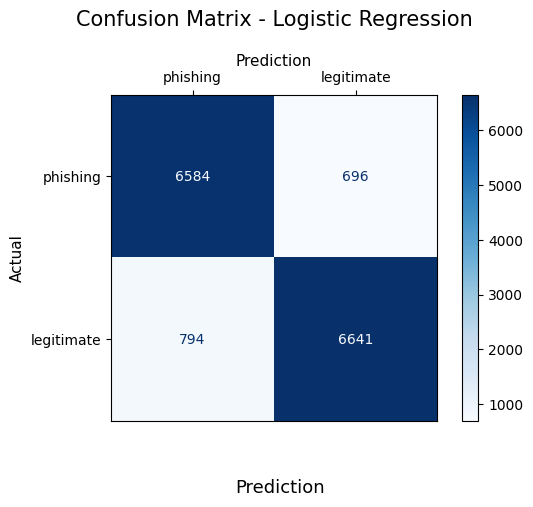

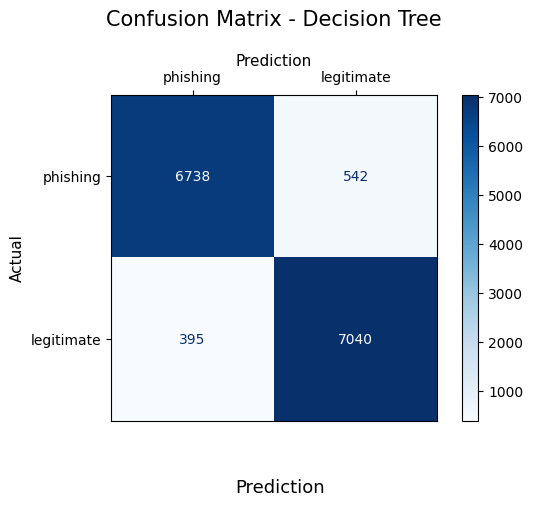

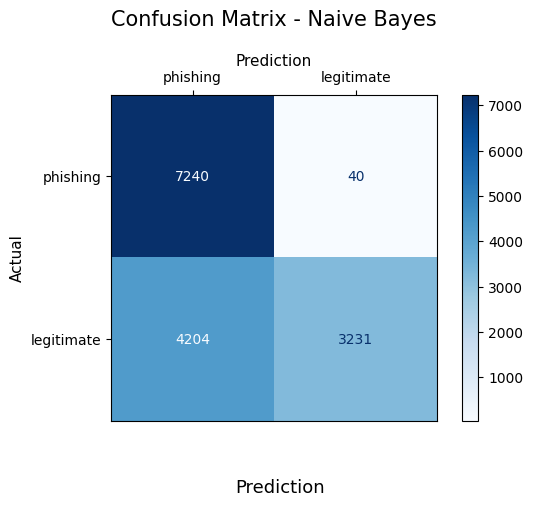

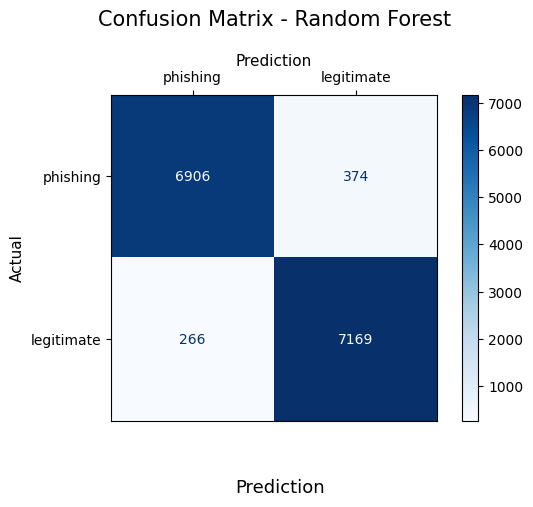

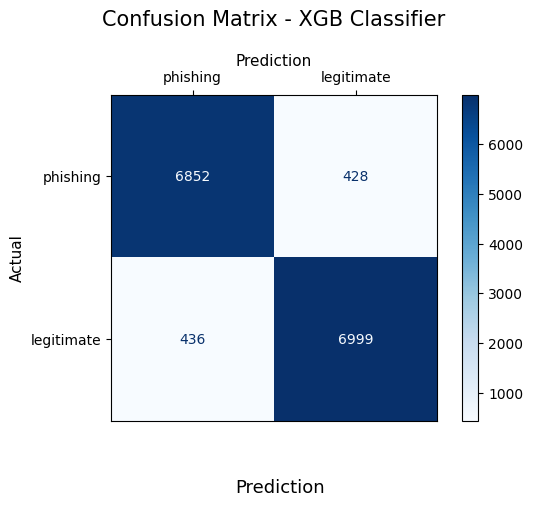

In [ ]:
#confustion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy

models = [lr, dt, nb, rf,xgb]
model_names = ['Logistic Regression','Decision Tree', 'Naive Bayes', 'Random Forest','XGB Classifier']
# Original class names for display purposes
class_names = ['phishing','legitimate']
# The actual labels in y_test are integers (0, 1, 2, 3)
# We need to pass these integer labels to confusion_matrix
actual_labels_in_ytest = np.unique(y_test) # Get the unique integer labels from y_test

for model, name in zip(models, model_names):
    test_data_prediction = model.predict(x_test)
    # Pass the actual integer labels from y_test to confusion_matrix
    # Use display_labels to map the integer labels to the string class names for the plot
    cm = confusion_matrix(y_test, test_data_prediction, labels=actual_labels_in_ytest)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Corrected line: use the colormap name as a string
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}', fontsize=15, pad=20)
    plt.xlabel('Prediction', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

    plt.show()

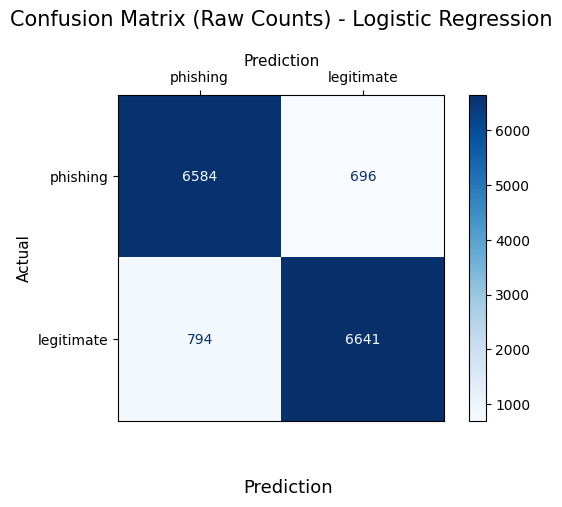

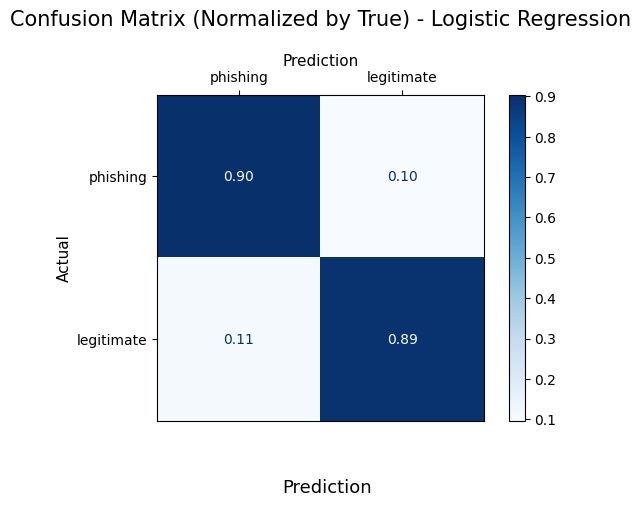

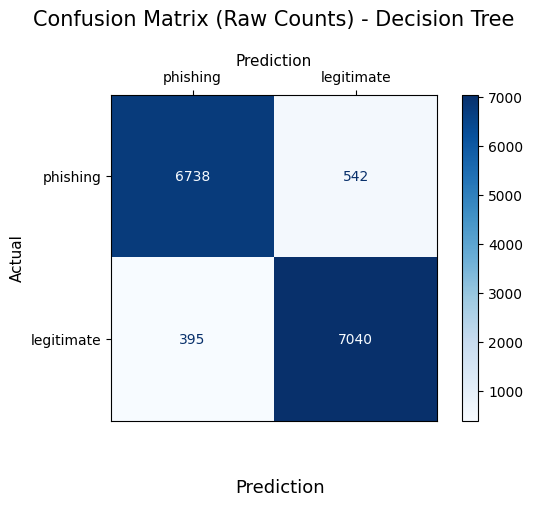

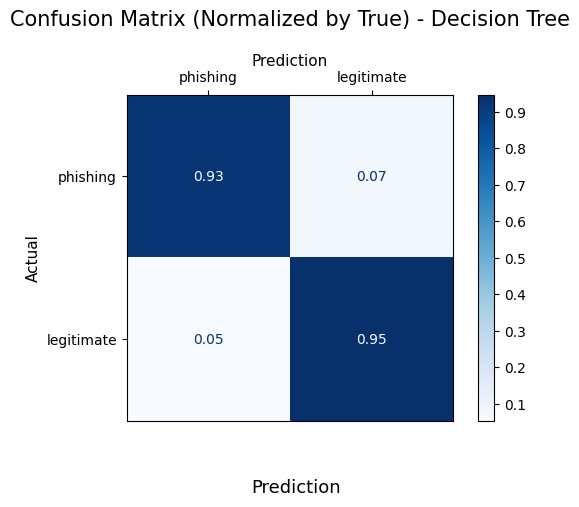

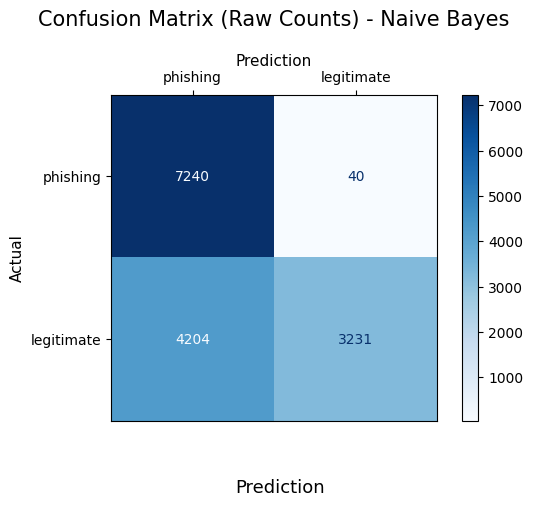

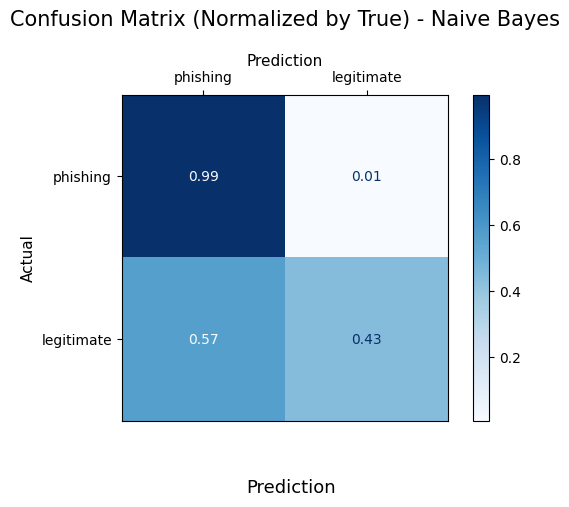

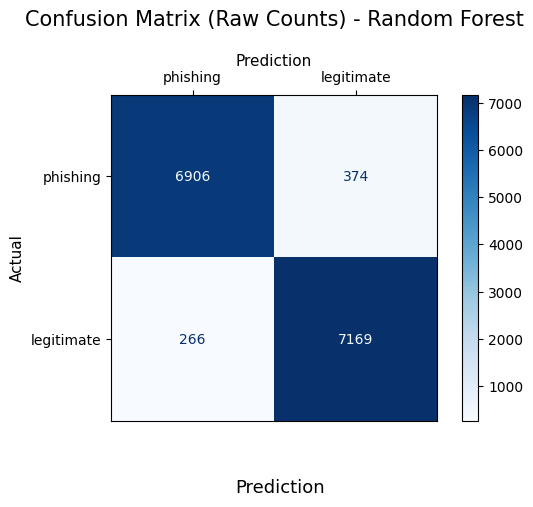

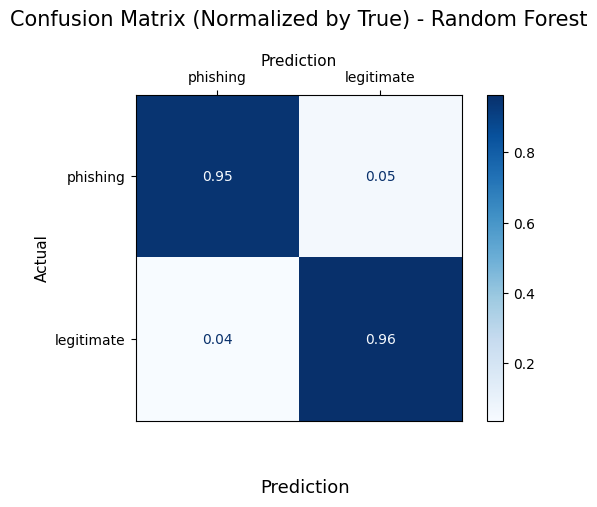

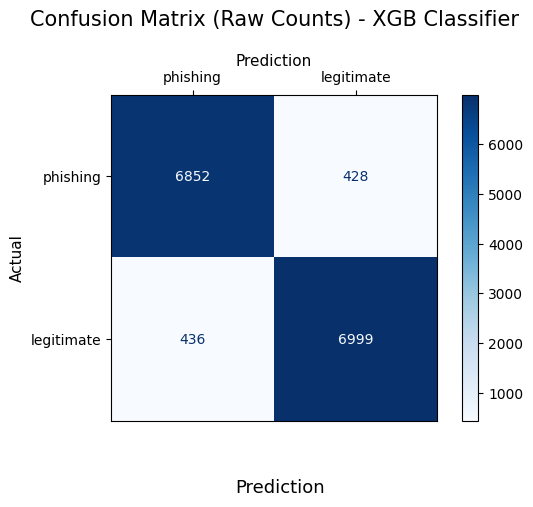

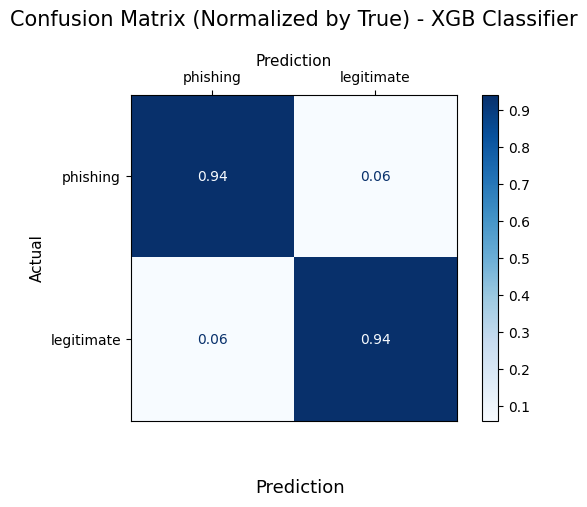

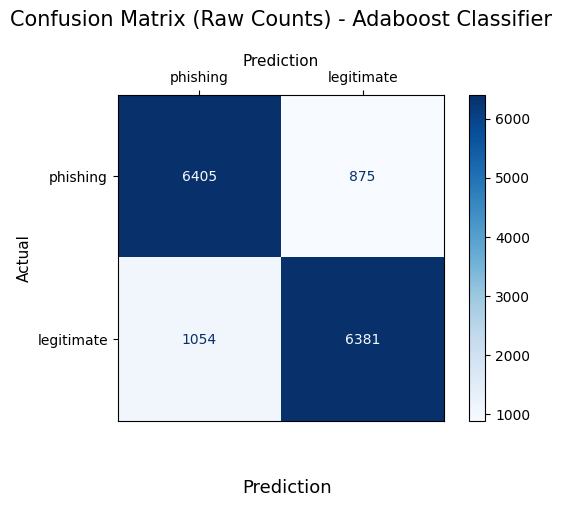

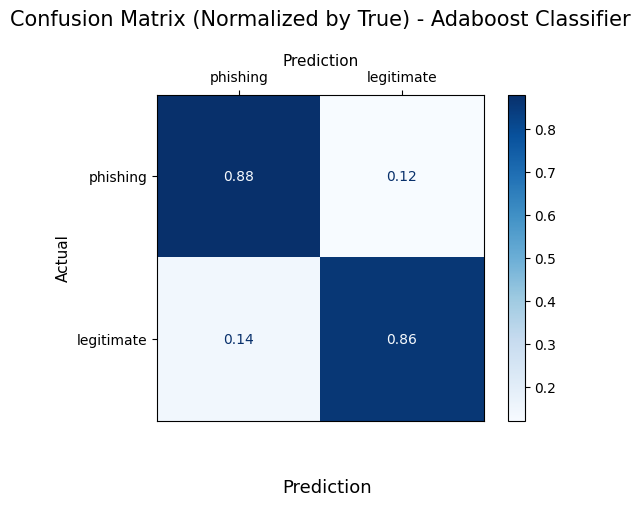

In [ ]:
#weighted confusion matrix
#weighted confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy

models = [lr, dt, nb, rf,xgb,ada]
model_names = ['Logistic Regression','Decision Tree', 'Naive Bayes', 'Random Forest','XGB Classifier','Adaboost Classifier']
# Original class names for display purposes
class_names = ['phishing','legitimate']
# The actual labels in y_test are integers (0, 1, 2)
# We need to pass these integer labels to confusion_matrix
actual_labels_in_ytest = np.unique(y_test) # Get the unique integer labels from y_test

for model, name in zip(models, model_names):
    test_data_prediction = model.predict(x_test)
    # Pass the actual integer labels from y_test to confusion_matrix

    # Calculate the confusion matrix (raw counts)
    cm = confusion_matrix(y_test, test_data_prediction, labels=actual_labels_in_ytest)

    # Calculate the normalized confusion matrix (normalized by rows - 'true' labels)
    # This shows the proportion of predictions for each actual class
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Display the RAW confusion matrix
    disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp_raw.plot(cmap='Blues', values_format='d') # Use 'd' to format as integers
    plt.title(f'Confusion Matrix (Raw Counts) - {name}', fontsize=15, pad=20)
    plt.xlabel('Prediction', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
    plt.show()

    # Display the NORMALIZED confusion matrix
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    # Use '.2f' to format as floats with 2 decimal places
    disp_norm.plot(cmap='Blues', values_format='.2f')
    plt.title(f'Confusion Matrix (Normalized by True) - {name}', fontsize=15, pad=20)
    plt.xlabel('Prediction', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
    plt.show()

# %%
#feature impotance


In [ ]:
#feature importance

In [ ]:
print("Counts of unique values in y_encoded (full dataset):", np.bincount(y_encoded))

Counts of unique values in y_encoded (full dataset): [36400 37175]


Expected: 2, Got: 1
Expected: 1, Got: 2


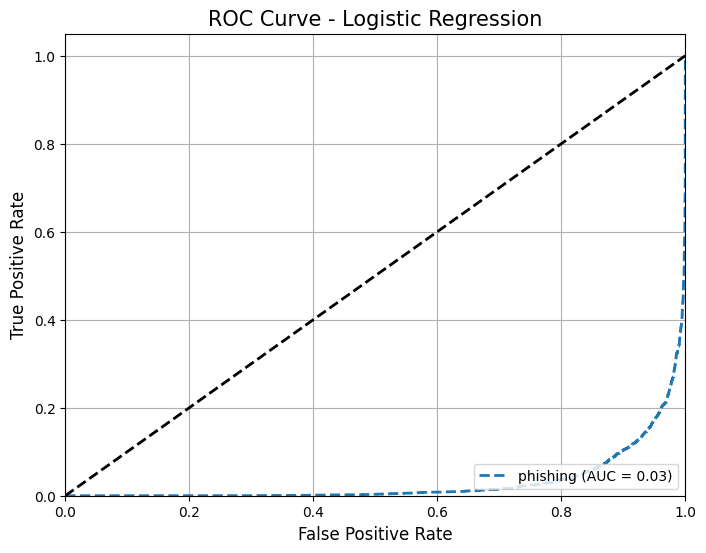

Expected: 1, Got: 2


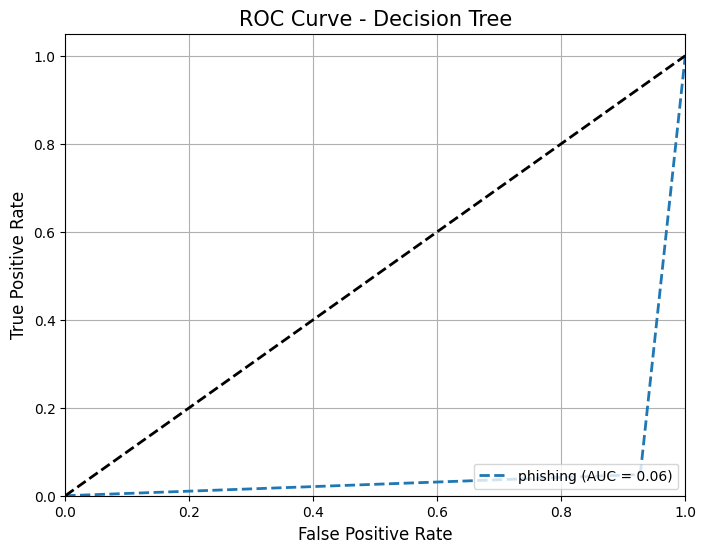

Expected: 1, Got: 2


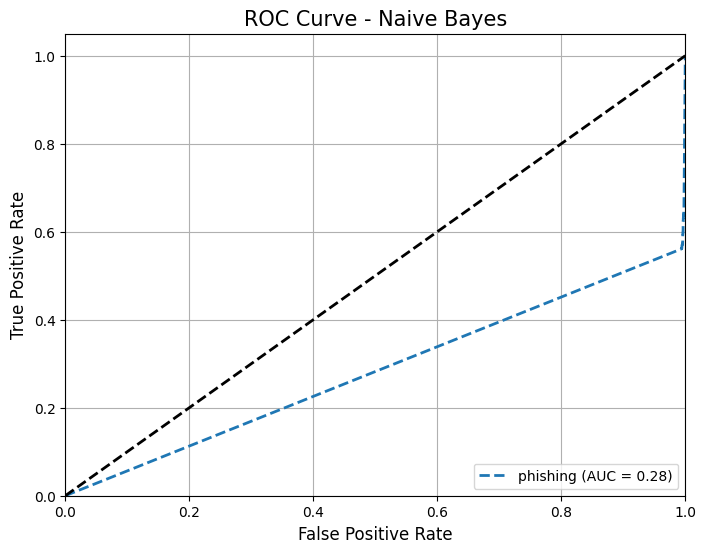

Expected: 1, Got: 2


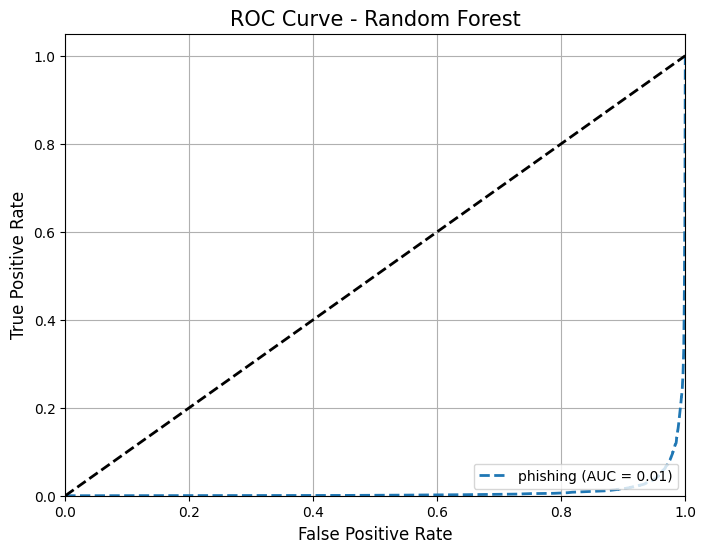

Expected: 1, Got: 2


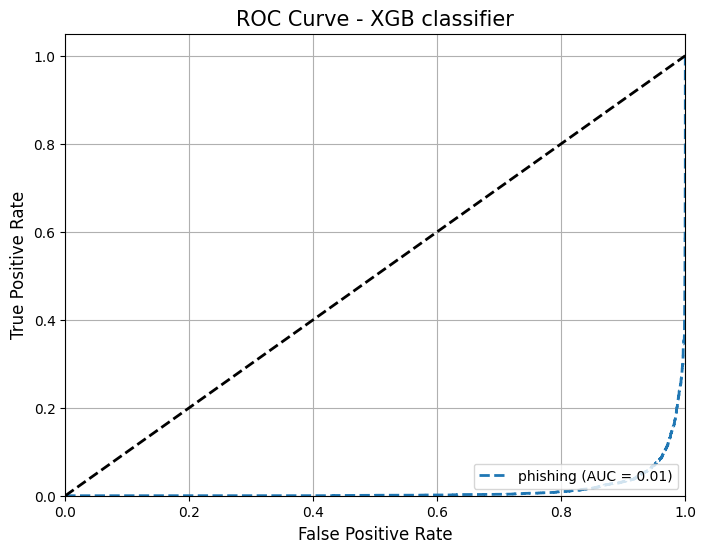

In [ ]:
#auc-roc curve for the above models
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
import numpy as np

models = [lr, dt, nb, rf,xgb]
model_names = ['Logistic Regression', 'Decision Tree', 'Naive Bayes', 'Random Forest','XGB classifier']
# Get the unique integer labels from y_test for binarization
actual_integer_classes = np.unique(y_test)
# Define class names for display purposes, corresponding to the integer labels
display_class_names = ['phishing','legitimate']

# Binarize the output labels using the actual integer classes
# Pass the actual integer classes found in y_test to label_binarize
y_test_bin = label_binarize(y_test, classes=actual_integer_classes)

# Check the shape of y_test_bin to ensure it has n_classes columns
if y_test_bin.shape[1] != len(actual_integer_classes):
    print("Warning: label_binarize did not produce the expected number of columns.")
    print(f"Expected: {len(actual_integer_classes)}, Got: {y_test_bin.shape[1]}")
    # Handle the error, perhaps by inspecting y_test and actual_integer_classes
    # For this specific case with 2 classes, this check is less critical
    # but useful for multi-class problems.

# Update n_classes based on the binarized output shape
n_classes = y_test_bin.shape[1]

for model, name in zip(models, model_names):
    # Predict probabilities
    y_score = model.predict_proba(x_test)

    # Check that y_score has the same number of columns as y_test_bin
    if y_score.shape[1] != n_classes:
         print(f"Warning: Model {name} predict_proba output shape mismatch.")
         print(f"Expected: {n_classes}, Got: {y_score.shape[1]}")
         # This might happen if a model only predicts one class (e.g., due to data imbalance)
         # For now, we'll proceed but this is a potential issue point.
         # For binary classification, y_score should have 2 columns.
         # If it has only 1, roc_curve(..., y_score[:, i]) will fail for i=1.
         # We need to ensure the model predicts probabilities for both classes.

    #roc curve for classes
    fpr={}
    tpr={}
    thresh={}
    roc_auc={}

    # Iterate through the actual integer classes present in the data
    # Use the index 'i' which corresponds to the column in y_test_bin and y_score
    for i in range(n_classes):
        # Ensure the current class index 'i' is within the bounds of y_test_bin and y_score
        if i < y_test_bin.shape[1] and i < y_score.shape[1]:
             # Calculate ROC curve for each class
             fpr[i], tpr[i], thresh[i] = roc_curve(y_test_bin[:, i], y_score[:, i])
             roc_auc[i] = auc(fpr[i], tpr[i])
        else:
             print(f"Skipping ROC calculation for class index {i} due to shape mismatch.")
             continue # Skip to the next iteration if index is out of bounds

    # Plot settings
    plt.figure(figsize=(8, 6))

    # Plot ROC curve for each class that was successfully calculated
    for i in roc_auc: # Iterate through the indices that have ROC data
        # Use display_class_names to get the string name for the class
        # Ensure the index 'i' is valid for display_class_names
        if i < len(display_class_names):
            plt.plot(fpr[i], tpr[i], linestyle='--', lw=2, label=f'{display_class_names[i]} (AUC = {roc_auc[i]:.2f})')
        else:
             print(f"Warning: Could not find display name for class index {i}.")
             plt.plot(fpr[i], tpr[i], linestyle='--', lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')


    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve - {name}', fontsize=15)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

In [ ]:
#top features that are contributing to the model

In [ ]:
#prediction model from the accuracy we can see random forest since it"s giving highest frequesncy

